## Подготовка данных

In [12]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = "gym_membership_churn.csv"
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Place the generated dataset in the notebook folder. Expected path: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Loaded", len(df), "rows")

price_min = df['membership_price'].min()
price_max = df['membership_price'].max()

df['price_norm'] = (df['membership_price'] - price_min) / (price_max - price_min + 1e-8)

df['engagement_score'] = (
    df.get('visits_last_4w', 0) * 0.6 +
    df.get('visits_prev_4w', 0) * 0.3 -
    df['days_since_last_visit'].fillna(0) * 0.1
)

df.drop(columns=['membership_price'], inplace=True, errors='ignore')

TARGET = 'churn'
FEATURES = df.columns.drop(TARGET).tolist()

cat_features = [c for c in ['gender'] if c in df.columns]
num_features = [c for c in FEATURES if c not in cat_features]

print("Dynamic price_norm range:", price_min, "–", price_max)
print("Features used:", len(FEATURES))
print("Categorical features:", cat_features)
print("Churn rate:", df[TARGET].mean().round(3))

X = df[FEATURES].copy()
y = df[TARGET].copy().astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
print('Random stratified split sizes:', X_train.shape, X_test.shape)

Loaded 5000 rows
Dynamic price_norm range: 1990 – 9990
Features used: 11
Categorical features: ['gender']
Churn rate: 0.28
Random stratified split sizes: (4000, 11) (1000, 11)


## Catboost

In [13]:
import optuna
from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 800, 4000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.5, 5.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.5),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'verbose': False,
        'early_stopping_rounds': 200,
        'class_weights': [1.0, pos_weight]
    }

    model = CatBoostClassifier(**params)

    model.fit(
        train_pool,
        eval_set=test_pool,
        use_best_model=True,
        verbose=False
    )

    pred_proba = model.predict_proba(test_pool)[:, 1]
    auc = roc_auc_score(y_test, pred_proba)
    return auc

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, timeout=1800)

print("Лучшие параметры:")
print(study.best_params)
print(f"Лучший ROC-AUC на валидации: {study.best_value:.5f}")

best_params = study.best_params
best_params.update({
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'verbose': 200,
    'early_stopping_rounds': 200,
    'class_weights': [1.0, pos_weight]
})

final_model = CatBoostClassifier(**best_params)
final_model.fit(train_pool, eval_set=test_pool, use_best_model=True)

y_pred_proba = final_model.predict_proba(test_pool)[:, 1]
y_pred = final_model.predict(test_pool)

os.makedirs("models", exist_ok=True)
final_model.save_model("../models/catboost_model.cbm")

[I 2026-03-28 12:25:02,122] A new study created in memory with name: no-name-d27bbf0a-790c-462f-a093-6cb077c49775
[I 2026-03-28 12:25:02,432] Trial 0 finished with value: 0.7854067460317461 and parameters: {'iterations': 1998, 'learning_rate': 0.13125830316209655, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'random_strength': 1.2020838819909643, 'bagging_temperature': 0.23399178050430397, 'border_count': 45}. Best is trial 0 with value: 0.7854067460317461.
[I 2026-03-28 12:25:02,809] Trial 1 finished with value: 0.7829265873015874 and parameters: {'iterations': 3572, 'learning_rate': 0.05092911283433821, 'depth': 8, 'l2_leaf_reg': 1.185260448662222, 'random_strength': 4.864594334728975, 'bagging_temperature': 1.2486639612006325, 'border_count': 79}. Best is trial 0 with value: 0.7854067460317461.
[I 2026-03-28 12:25:03,330] Trial 2 finished with value: 0.7804811507936507 and parameters: {'iterations': 1382, 'learning_rate': 0.016432378919707624, 'depth': 6, 'l2_leaf_reg': 5.722807884

Лучшие параметры:
{'iterations': 1391, 'learning_rate': 0.13814017620274424, 'depth': 9, 'l2_leaf_reg': 9.455490474077703, 'random_strength': 4.526723076924419, 'bagging_temperature': 0.8968499682166278, 'border_count': 238}
Лучший ROC-AUC на валидации: 0.79155
0:	test: 0.7734003	best: 0.7734003 (0)	total: 2.13ms	remaining: 2.96s
200:	test: 0.7597619	best: 0.7915451 (56)	total: 429ms	remaining: 2.54s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7915451389
bestIteration = 56

Shrink model to first 57 iterations.


## XGBoost

In [21]:
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

transformers = []
if len(cat_features) > 0:
    transformers.append(
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features,
        )
    )
if len(num_features) > 0:
    transformers.append(
        (
            "num",
            "passthrough",
            num_features,
        )
    )

if not transformers:
    raise ValueError("No features found for preprocessing")

preprocess = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
)

X_train_t = preprocess.fit_transform(X_train)
X_test_t = preprocess.transform(X_test)

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = float(neg / max(pos, 1))

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

xgb_model.fit(X_train_t, y_train)

xgb_pred = (xgb_model.predict_proba(X_test_t)[:, 1] >= 0.5).astype(int)
xgb_pred_proba = xgb_model.predict_proba(X_test_t)[:, 1]

os.makedirs("models", exist_ok=True)
xgb_model.save_model("../models/xgboost_model.json")


## LightGBM

In [15]:
from lightgbm import LGBMClassifier

X_train_lgb = preprocess.transform(X_train)
X_test_lgb = preprocess.transform(X_test)

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = float(neg / max(pos, 1))

lgb_model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
)

feature_names = list(preprocess.get_feature_names_out())

lgb_model.fit(
    X_train_lgb,
    y_train,
    feature_name=feature_names,
)

lgb_pred_proba = lgb_model.predict_proba(X_test_lgb)[:, 1]
lgb_pred = (lgb_pred_proba >= 0.5).astype(int)

os.makedirs("models", exist_ok=True)
lgb_model.booster_.save_model("../models/lightgbm_model.txt")


[LightGBM] [Info] Number of positive: 1121, number of negative: 2879
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 659
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.280250 -> initscore=-0.943222
[LightGBM] [Info] Start training from score -0.943222


/Users/ultar/PycharmProjects/ZPassFitAI/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Сравнение

,model,accuracy,roc_auc,precision,recall,f1
0,CatBoost,0.747,0.791545,0.543131,0.607143,0.573356
1,XGBoost,0.727,0.774184,0.510769,0.592857,0.548760
2,LightGBM,0.743,0.730987,0.547718,0.471429,0.506718


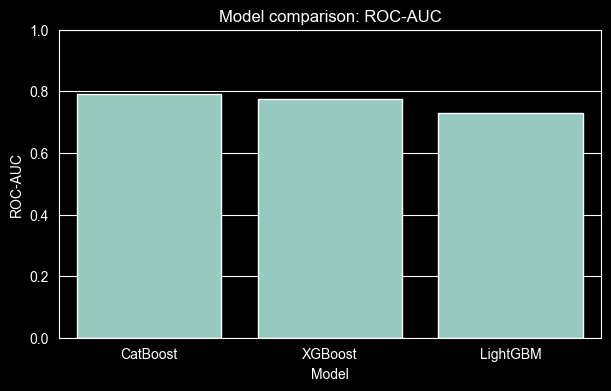

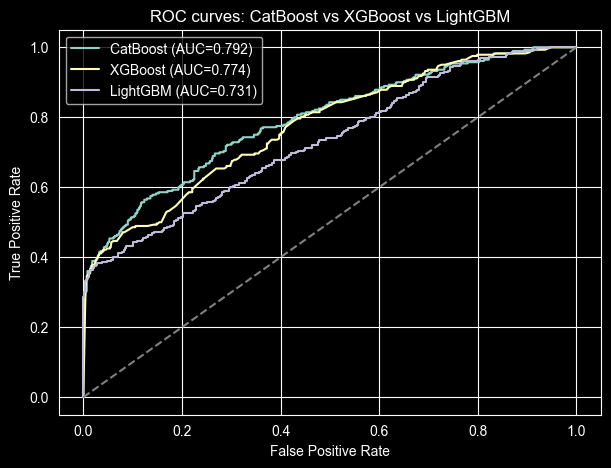

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
)

results = [{
    "model": "CatBoost",
    "accuracy": accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_pred_proba),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
}, {
    "model": "XGBoost",
    "accuracy": accuracy_score(y_test, xgb_pred),
    "roc_auc": roc_auc_score(y_test, xgb_pred_proba),
    "precision": precision_score(y_test, xgb_pred, zero_division=0),
    "recall": recall_score(y_test, xgb_pred, zero_division=0),
    "f1": f1_score(y_test, xgb_pred, zero_division=0),
}, {
    "model": "LightGBM",
    "accuracy": accuracy_score(y_test, lgb_pred),
    "roc_auc": roc_auc_score(y_test, lgb_pred_proba),
    "precision": precision_score(y_test, lgb_pred, zero_division=0),
    "recall": recall_score(y_test, lgb_pred, zero_division=0),
    "f1": f1_score(y_test, lgb_pred, zero_division=0),
}]

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)

# Bar chart ROC-AUC
plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x="model", y="roc_auc")
plt.ylim(0.0, 1.0)
plt.title("Model comparison: ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.show()

# ROC curves
plt.figure(figsize=(7, 5))

fpr_c, tpr_c, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr_c, tpr_c, label=f"CatBoost (AUC={roc_auc_score(y_test, y_pred_proba):.3f})")

fpr_x, tpr_x, _ = roc_curve(y_test, xgb_pred_proba)
plt.plot(fpr_x, tpr_x, label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_pred_proba):.3f})")

fpr_l, tpr_l, _ = roc_curve(y_test, lgb_pred_proba)
plt.plot(fpr_l, tpr_l, label=f"LightGBM (AUC={roc_auc_score(y_test, lgb_pred_proba):.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves: CatBoost vs XGBoost vs LightGBM")
plt.legend()
plt.show()